# Branin (2D) GFlowNet-Guided BO

This notebook compares two BO policies on `branin`:

- `random`: block-wise dropout masks are sampled uniformly at random.
- `gfn`: a contextual GFlowNet is trained to generate masks with probability proportional to proxy improvement potential.

The implementation lives in `gfn_bo_experiments.py`, so the same surrogate, reward, and evaluation code is reused across all benchmarks.


## Notes

- The GFlowNet is re-trained or fine-tuned at every BO step on the current surrogate, using a dataset-statistics context vector.
- Proxy rewards are computed from held-out random masks to reduce overfitting to a single overconfident surrogate interpretation.
- If the full configuration is too slow on your machine, reduce `cfg.seeds`, `cfg.n_iter`, `cfg.gfn_steps`, or `cfg.n_candidates`.


In [1]:
from gfn_bo_experiments import (
    default_config,
    plot_proxy_diagnostics,
    plot_regret_comparison,
    print_comparison_table,
    run_benchmark_comparison,
)

benchmark_name = "branin"
cfg = default_config(benchmark_name, seeds=[0, 1, 2, 3, 4])
cfg


ExperimentConfig(n_init=8, n_iter=18, seeds=[0, 1, 2, 3, 4], surrogate_hidden_dim=64, surrogate_dropout_p=0.1, surrogate_epochs=300, surrogate_lr=0.001, block_size=8, n_candidates=2048, heldout_mask_samples=24, random_mask_samples=96, gfn_mask_samples=96, gfn_hidden_size=128, gfn_steps=160, gfn_batch_size=16, gfn_lr=0.001, proxy_beta=0.6, reward_temperature=0.5, continual_finetune=True)

In [2]:
results = run_benchmark_comparison(benchmark_name, cfg)
print_comparison_table(results)


Method        Final regret (mean +- std)    Final best value (mean +- std)
random      1.7813 +- 1.1734        -2.1792 +- 1.1734
gfn         2.1459 +- 0.7910        -2.5438 +- 0.7910


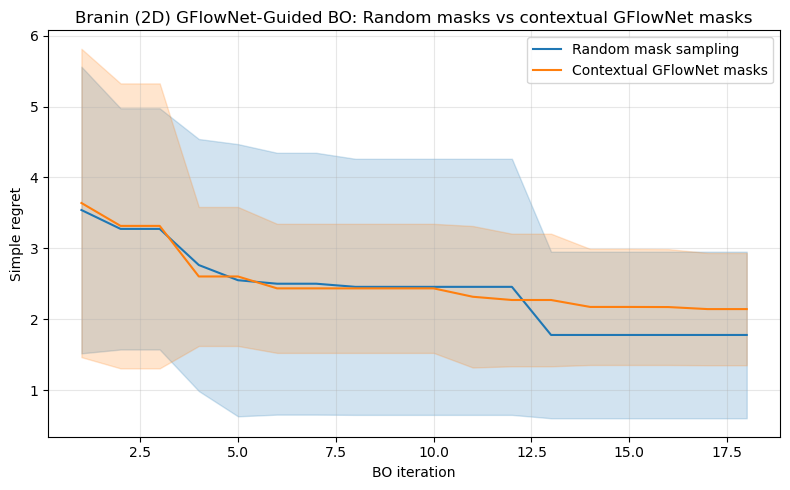

In [3]:
plot_regret_comparison(
    results,
    title="Branin (2D) GFlowNet-Guided BO: Random masks vs contextual GFlowNet masks",
)


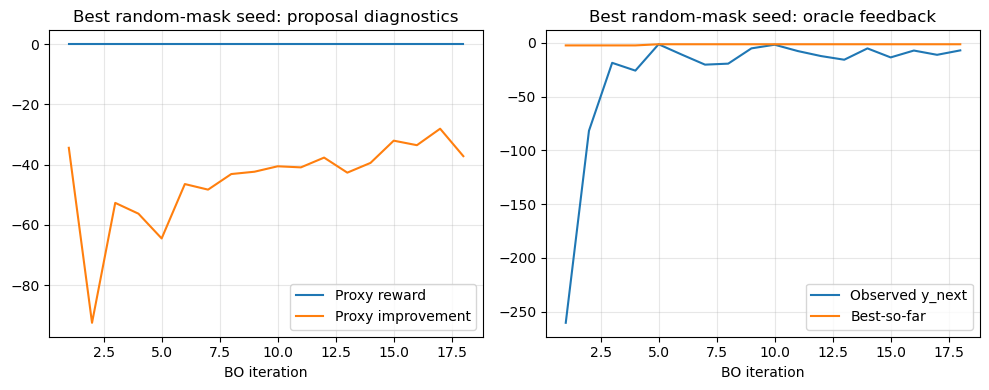

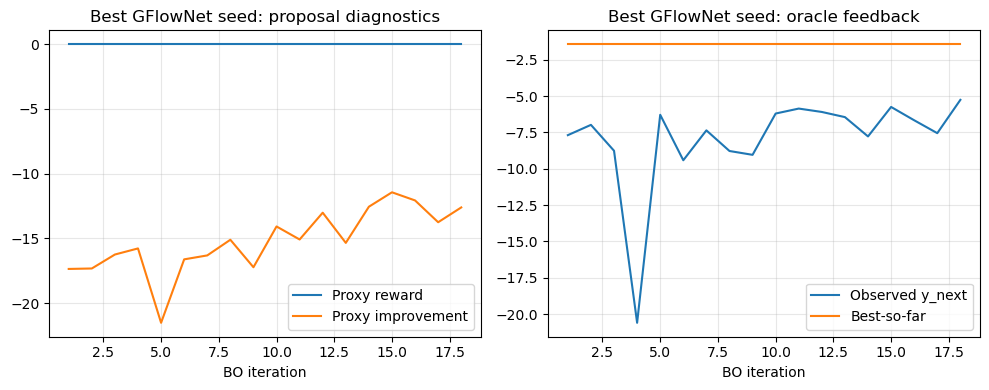

In [4]:
random_trial = min(
    results["random"]["trials"],
    key=lambda trial: trial["regrets"][-1],
)
gfn_trial = min(
    results["gfn"]["trials"],
    key=lambda trial: trial["regrets"][-1],
)

plot_proxy_diagnostics(random_trial, "Best random-mask seed")
plot_proxy_diagnostics(gfn_trial, "Best GFlowNet seed")


In [5]:
random_final = results["random"]["summary"]["final_regret_mean"]
gfn_final = results["gfn"]["summary"]["final_regret_mean"]
improvement = random_final - gfn_final

print(f"Mean final regret (random): {random_final:.4f}")
print(f"Mean final regret (gfn)   : {gfn_final:.4f}")
print(f"Absolute regret gain      : {improvement:.4f}")


Mean final regret (random): 1.7813
Mean final regret (gfn)   : 2.1459
Absolute regret gain      : -0.3646
